# K-Means Clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing the dataset

In [9]:
dataset = pd.read_csv('../Data/Mall_Customers.csv')
dataset

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [11]:
X = dataset.iloc[:, 1:] # first col doesn't signify anything in the dataset
X

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


## Encode the data categorical column

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(), [0])], remainder = 'passthrough')
X = np.array(ct.fit_transform(X))
X

array([[  0.,   1.,  19.,  15.,  39.],
       [  0.,   1.,  21.,  15.,  81.],
       [  1.,   0.,  20.,  16.,   6.],
       [  1.,   0.,  23.,  16.,  77.],
       [  1.,   0.,  31.,  17.,  40.],
       [  1.,   0.,  22.,  17.,  76.],
       [  1.,   0.,  35.,  18.,   6.],
       [  1.,   0.,  23.,  18.,  94.],
       [  0.,   1.,  64.,  19.,   3.],
       [  1.,   0.,  30.,  19.,  72.],
       [  0.,   1.,  67.,  19.,  14.],
       [  1.,   0.,  35.,  19.,  99.],
       [  1.,   0.,  58.,  20.,  15.],
       [  1.,   0.,  24.,  20.,  77.],
       [  0.,   1.,  37.,  20.,  13.],
       [  0.,   1.,  22.,  20.,  79.],
       [  1.,   0.,  35.,  21.,  35.],
       [  0.,   1.,  20.,  21.,  66.],
       [  0.,   1.,  52.,  23.,  29.],
       [  1.,   0.,  35.,  23.,  98.],
       [  0.,   1.,  35.,  24.,  35.],
       [  0.,   1.,  25.,  24.,  73.],
       [  1.,   0.,  46.,  25.,   5.],
       [  0.,   1.,  31.,  25.,  73.],
       [  1.,   0.,  54.,  28.,  14.],
       [  0.,   1.,  29.,

## Using elbow method to find optimal no. of clusters

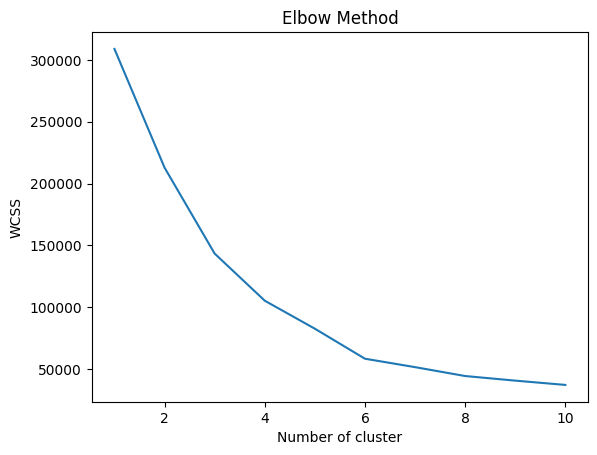

In [14]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    model = KMeans(n_clusters = i, init = 'k-means++', random_state = 0)
    model.fit(X)
    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel('Number of cluster')
plt.ylabel('WCSS')
plt.show()

## Training the K-Means Model

In [16]:
model = KMeans(n_clusters = 5, init = 'k-means++', random_state = 0)
y_kmeans = model.fit_predict(X)

In [17]:
print(y_kmeans)

[2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 4 4 4 0 4 4 0 0 0 0 0 4 0 0 4 0 0 0 4 4 0 4 4 0 0 0 0
 0 4 4 4 4 0 0 4 0 4 4 4 4 4 4 4 0 4 4 4 4 4 4 4 4 4 4 4 0 4 4 4 0 4 0 0 0
 4 4 4 4 4 0 4 4 4 4 4 4 1 4 1 4 1 3 1 3 1 4 1 3 1 3 1 3 1 3 1 4 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]
